## A ~8M dense transformer trained on 3-digit addition, written in JAX

Hyperparams

* `n_layers` = 12
*  `d_model` = 256
*  `d_ff` = 1024
*  `n_heads` = 16
*  `n_kv_heads` = 2
*  `d_qkv` = 16
*  `n_embed` = 13

Total params: $2D(N+K)HL + 2DFL + 2DV = 8.07e6$ (~8M)

In [ ]:
!pip install --upgrade jax

In [1]:
import jax
import jax.numpy as jnp
from jax import lax, grad, random
from jax.sharding import PartitionSpec as P

from flax import struct
import optax

import numpy as np
from functools import partial

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
# jax.config.update("jax_num_cpu_devices", 8) # simulate 8 devices -> disable later

jax.devices()

E0000 00:00:1786272089.788761    6272 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0),
 TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0),
 TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0),
 TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0),
 TpuDevice(id=4, process_index=0, coords=(0,2,0), core_on_chip=0),
 TpuDevice(id=5, process_index=0, coords=(1,2,0), core_on_chip=0),
 TpuDevice(id=6, process_index=0, coords=(0,3,0), core_on_chip=0),
 TpuDevice(id=7, process_index=0, coords=(1,3,0), core_on_chip=0)]

In [3]:
X, Y = 8, 1


mesh = jax.make_mesh((X, Y), ('X', 'Y')) # default Explicit
jax.set_mesh(mesh)

## Building the model

In [4]:
@struct.dataclass
class Config:
    n_layers: jnp.int32

    d_model: jnp.int32
    d_ff: jnp.int32

    n_heads: jnp.int32
    n_kv_heads: jnp.int32

    d_qkv: jnp.int32
    n_embed: jnp.int32

    max_seq_len: jnp.int32
    
    dtype: jnp.dtype = jnp.bfloat16
    param_dtype: jnp.dtype = jnp.float32

In [5]:
def init_params(cfg: Config, rng: random.key) -> dict:
    
    embed_key, unembed_key, rng = random.split(rng, 3)

    params = {}
    
    params["W_embed"] = random.normal(embed_key, (cfg.n_embed, cfg.d_model), dtype=cfg.param_dtype) * 0.02
    params["W_unembed"] = random.normal(unembed_key, (cfg.d_model, cfg.n_embed), dtype=cfg.param_dtype) * 0.02

    initializer = jax.nn.initializers.glorot_normal()
    initializer_attn = jax.nn.initializers.glorot_normal(in_axis=0, out_axis=(1, 2))
    initializer_proj = jax.nn.initializers.glorot_normal(in_axis=(0, 1), out_axis=2)
    
    params["layers"] = []
    for i in range(cfg.n_layers):
        layer_params = {}
        
        q_key, k_key, v_key, o_key, in_key, out_key, rng = random.split(rng, 7)
        
        layer_params["W_q"] = initializer_attn(q_key, (cfg.d_model, cfg.n_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        layer_params["W_k"] = initializer_attn(k_key, (cfg.d_model, cfg.n_kv_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        layer_params["W_v"] = initializer_attn(v_key, (cfg.d_model, cfg.n_kv_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        
        layer_params["W_o"] = initializer_proj(o_key, (cfg.n_heads, cfg.d_qkv, cfg.d_model), dtype=cfg.param_dtype)

        layer_params["W_in"] = initializer(in_key, (cfg.d_model, cfg.d_ff), dtype=cfg.param_dtype)
        layer_params["W_out"] = initializer(out_key, (cfg.d_ff, cfg.d_model), dtype=cfg.param_dtype)

        layer_params["gamma1"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
        layer_params["beta1"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)

        layer_params["gamma2"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
        layer_params["beta2"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)

        params["layers"].append(layer_params)

    return params

In [6]:
def RoPE(x: jnp.array) -> jnp.array:

    H = x.shape[-1]
    T = x.shape[1]
    
    assert H % 2 == 0

    base = 10000
    exp = -2 * jnp.arange(H//2, dtype=x.dtype) / H
    theta = jnp.arange(T).reshape(T, 1) * jnp.float_power(base, exp)

    cos_vec = jnp.cos(theta).reshape(1, T, 1, H//2)
    sin_vec = jnp.sin(theta).reshape(1, T, 1, H//2)

    x1, x2 = jnp.split(x, 2, axis=-1)

    x1_new = x1 * cos_vec - x2 * sin_vec
    x2_new = x1 * sin_vec + x2 * cos_vec

    return jnp.concatenate([x1_new, x2_new], axis=-1, dtype=x.dtype)

In [7]:
def attention(x: jnp.array, W_q: jnp.array, W_k: jnp.array, W_v: jnp.array, W_o: jnp.array, attn_mask: jnp.array = None, is_causal: bool = True) -> jnp.array:

    B = x.shape[0]
    T = x.shape[1] # assume T == S
    
    N = W_q.shape[1]
    K = W_k.shape[1]
    H = W_q.shape[-1]

    assert N % K == 0
    
    q = jnp.einsum('btd,dnh->btnh', x, W_q)
    k = jnp.einsum('bsd,dnh->bsnh', x, W_k)
    v = jnp.einsum('bsd,dnh->bsnh', x, W_v)

    q = RoPE(q)
    k = RoPE(k)

    q = q.reshape((B, T, K, -1, H))

    s = jnp.einsum('btkgh,bskh->btskg', q, k)

    s /= jnp.sqrt(H)
    
    if (attn_mask is not None or is_causal): 
    
        mask = jnp.ones((B, T, T), dtype=x.dtype)

        if (is_causal):
            mask = jnp.tril(mask)
        
        if (attn_mask is not None):
            mask = mask * attn_mask.reshape((B, -1, T))

        mask = mask.reshape((B, T, T, 1, 1))
        
        s = jnp.where(mask, s, -jnp.inf)

    # s = jnp.exp(s) / jnp.sum(jnp.exp(s), axis=2, keepdims=True) # softmax
    s = jax.nn.softmax(s, axis=2)

    a = jnp.einsum('btskg,bskh->btkgh', s, v)
    a = a.reshape((B, T, N, H))

    out = jnp.einsum('btnh,nhd->btd', a, W_o)
    return out

In [8]:
def mlp(x: jnp.array, W_in: jnp.array, W_out: jnp.array) -> jnp.array: 

    ffw_in = jnp.einsum('btd,df->btf', x, W_in)

    ffw_in = jax.nn.gelu(ffw_in)

    ffw_out = jnp.einsum('btf,fd->btd', ffw_in, W_out)

    return ffw_out

In [9]:
def layerNorm(x: jnp.array, gamma: jnp.array, beta: jnp.array) -> jnp.array:

    mu = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)

    epsilon = 1e-5
    tmp = (x - mu) / jnp.sqrt(var + epsilon)

    return gamma * tmp + beta

In [10]:
def transformer_block(layer_params: optax.Params, x: jnp.array, attn_mask: jnp.array = None) -> jnp.array:

    # pre-norm
    
    gamma1 = layer_params["gamma1"]
    beta1 = layer_params["beta1"]
    
    x_norm = layerNorm(x, gamma1, beta1)

    # attention
    
    W_q = layer_params["W_q"]
    W_k = layer_params["W_k"]
    W_v = layer_params["W_v"]
    W_o = layer_params["W_o"]
    
    attn_out = attention(x_norm, W_q, W_k, W_v, W_o, attn_mask=attn_mask, is_causal=True)

    attn_out = attn_out + x # residue connection

    # norm

    gamma2 = layer_params["gamma2"]
    beta2 = layer_params["beta2"]
    
    attn_norm = layerNorm(attn_out, gamma2, beta2)

    # mlp

    W_in = layer_params["W_in"]
    W_out = layer_params["W_out"]

    ffw_out = mlp(attn_norm, W_in, W_out)

    ffw_out = ffw_out + attn_out # residue connection
    
    return ffw_out

In [11]:
def forward(params: optax.Params, x: jnp.array, attn_mask: jnp.array = None) -> jnp.array:

    W_embed = params["W_embed"]
    
    x = jnp.einsum("btv,vd->btd", x, W_embed) # embedding

    for layer_params in params["layers"]:
        x = transformer_block(layer_params, x, attn_mask=attn_mask)

    #TODO: implement final LN (before unembedding)
    
    W_unembed = params["W_unembed"]
    
    out = jnp.einsum("btd,dv->btv", x, W_unembed) # unembedding

    return out

## Building the dataset

3-digit addition

In [22]:
seq_len = 16


# all possible combinations

n_samples = 1000 * 1000

A1 = np.tile(np.arange(1000), 1000)
A2 = np.arange(1000).repeat(1000)

A = np.stack([A1, A2, A1+A2])


# select sample

# n_samples = 10000

# rng = np.random.default_rng()

# A1 = rng.integers(low=0, high=1000, size=n_samples)
# A2 = rng.integers(low=0, high=1000, size=n_samples)
# A = np.stack([A1, A2, A1+A2])

In [23]:
A_size = np.strings.str_len(A.astype(np.str_))

A = A[2] + A[1] * (10 ** (A_size[2]+3)) + A[0] * (10 ** (A_size[2]+A_size[1]+6))

A_size_comb = np.strings.str_len(A.astype(np.str_))

A = A * (10 ** (seq_len - A_size_comb))

In [24]:
X = np.zeros((n_samples, seq_len))

for i in range(seq_len):
    X[:, seq_len-i-1] = A % 10
    A //= 10

X.put(np.arange(n_samples)*16 + A_size[0] + 1, 11) # inserting addition signs

X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 4, 12) # inserting equal signs


attn_masks = np.where(np.indices((n_samples, seq_len))[1] < (A_size.sum(axis=0) + 6).reshape(n_samples, 1), 1, 0) # masks out the padding

loss_masks = np.where(np.indices((n_samples, seq_len))[1] < (A_size.sum(axis=0) + 5).reshape(n_samples, 1), 1, 0) # masks out padding + last position
loss_masks *= np.where(np.indices((n_samples, seq_len))[1] >= (A_size[0] + A_size[1] + 5).reshape(n_samples, 1), 1, 0) # masks out everything before ans (not including last space)

# inserting space signs
X.put(np.arange(n_samples)*16 + A_size[0], 10)
X.put(np.arange(n_samples)*16 + A_size[0] + 2, 10)
X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 3, 10) 
X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 5, 10) 

X += (1 - attn_masks) * 10 # set padding to space bars

In [25]:
Y = X[:, 1:]
Y = np.pad(Y, ((0,0), (0,1)), constant_values=10)

In [26]:
rng = np.random.default_rng()

perm = np.arange(n_samples)
rng.shuffle(perm)

X = X[perm]
Y = Y[perm]
attn_masks = attn_masks[perm]
loss_masks = loss_masks[perm]

In [27]:
X.shape, Y.shape

((1000000, 16), (1000000, 16))

In [29]:
print(X[0])
print(Y[0])
print(attn_masks[0])
print(loss_masks[0])

[ 9.  4.  9. 10. 11. 10.  4.  9.  2. 10. 12. 10.  1.  4.  4.  1.]
[ 4.  9. 10. 11. 10.  4.  9.  2. 10. 12. 10.  1.  4.  4.  1. 10.]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0]


## Training the model

Using batch size = 4000 sequences as $\frac{B}{X} > \frac{C}{W_{ici}} => B > \frac{CX}{W_{ici}} \approx 35000$, where $B$ denotes batch size in tokens

In [30]:
@partial(
    jax.jit,
    static_argnames=["optimizer"]
)
def train_step(params: optax.Params, state: optax.Params, optimizer: optax.GradientTransformation, x: jnp.array, y: jnp.array, attn_mask: jnp.array = None, loss_mask: jnp.array = None):

    def loss_fn(params: optax.Params):
        logits = forward(params, x, attn_mask)
        loss = optax.losses.softmax_cross_entropy(logits, y)

        if (loss_mask is not None):
            return (loss * loss_mask).sum() / loss_mask.sum()
    
        return loss.mean()
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, state = optimizer.update(grads, state, params)
    params = optax.apply_updates(params, updates)

    return params, state, loss

In [31]:
@jax.jit
def eval_step(params: optax.Params, x: jnp.array, y: jnp.array, attn_mask: jnp.array = None, loss_mask: jnp.array = None):

    def loss_fn(params: optax.Params):
        logits = forward(params, x, attn_mask)
        loss = optax.losses.softmax_cross_entropy(logits, y)

        if (loss_mask is not None):
            return (loss * loss_mask).sum() / loss_mask.sum()
    
        return loss.mean()
    
    loss = loss_fn(params)

    return loss

In [32]:
cfg = Config(
    n_layers = 12,
    d_model = 256,
    d_ff = 1024,
    n_heads = 16,
    n_kv_heads = 2,
    d_qkv = 16,
    n_embed = 13,
    max_seq_len = 16
)


# batch_size = 400 # change to 4000 for training
batch_size = 4000 

assert(n_samples % batch_size == 0)

n_epochs = 20

In [33]:
schedule = optax.schedules.cosine_decay_schedule(
    init_value = 2e-4,
    decay_steps = n_epochs * (n_samples // batch_size),
    alpha = 0.1
)

optimizer = optax.adamw(
    learning_rate = schedule
)

In [34]:
params = init_params(cfg, random.key(42))

state = optimizer.init(params)

In [35]:
X = jnp.array(X)
Y = jnp.array(Y)

loss_masks = jnp.array(loss_masks, dtype=cfg.dtype)
attn_masks = jnp.array(attn_masks, dtype=cfg.dtype)

# X.shape, Y.shape, loss_masks.shape, attn_masks.shape

X = X.reshape((-1, batch_size, seq_len))
Y = Y.reshape((-1, batch_size, seq_len))
loss_masks = loss_masks.reshape((-1, batch_size, seq_len))
attn_masks = attn_masks.reshape((-1, batch_size, seq_len))


# sharding = simple data parallelism

X = jax.device_put(X, P(None, 'X', None))
Y = jax.device_put(Y, P(None, 'X', None))
loss_masks = jax.device_put(loss_masks, P(None, 'X', None))
attn_masks = jax.device_put(attn_masks, P(None, 'X', None))

X.shape, Y.shape, loss_masks.shape, attn_masks.shape

((250, 4000, 16), (250, 4000, 16), (250, 4000, 16), (250, 4000, 16))

In [36]:
train_test_ratio = 0.8

n_train = int(train_test_ratio * X.shape[0])

X_train, X_test = jnp.array_split(X, (n_train,))
Y_train, Y_test = jnp.array_split(Y, (n_train,))

loss_masks_train, loss_masks_test = jnp.array_split(loss_masks, (n_train,))
attn_masks_train, attn_masks_test = jnp.array_split(attn_masks, (n_train,))

X_train.shape, Y_train.shape, loss_masks_train.shape, attn_masks_train.shape

((200, 4000, 16), (200, 4000, 16), (200, 4000, 16), (200, 4000, 16))

In [37]:
train_losses = []
eval_losses = []

for i in range(n_epochs):

    # train
    
    train_loss = 0.0
    
    for x, y, loss_mask, attn_mask in zip(X_train, Y_train, loss_masks_train, attn_masks_train): 
    
        x = jax.nn.one_hot(x, num_classes=cfg.n_embed, dtype=cfg.dtype)
        y = jax.nn.one_hot(y, num_classes=cfg.n_embed, dtype=cfg.dtype)
        
        params, state, loss = train_step(params, state, optimizer, x, y, attn_mask, loss_mask)

        train_loss += loss

    train_loss /= X_train.shape[0]


    # evaluate
    
    eval_loss = 0.0

    for x, y, loss_mask, attn_mask in zip(X_test, Y_test, loss_masks_test, attn_masks_test): 

        x = jax.nn.one_hot(x, num_classes=cfg.n_embed, dtype=cfg.dtype)
        y = jax.nn.one_hot(y, num_classes=cfg.n_embed, dtype=cfg.dtype)
        
        loss = eval_step(params, x, y, attn_mask, loss_mask)

        eval_loss += loss

    eval_loss /= X_test.shape[0]
    
    print(f"Epoch {i}: Train loss = {train_loss}, Eval loss = {eval_loss}")

    train_losses.append(train_loss)
    eval_losses.append(eval_loss)

Epoch 0: Train loss = 1.5637353658676147, Eval loss = 0.5674782395362854
Epoch 1: Train loss = 0.200026273727417, Eval loss = 0.05240435153245926
Epoch 2: Train loss = 1.0518391132354736, Eval loss = 0.43774735927581787
Epoch 3: Train loss = 0.18396936357021332, Eval loss = 0.09464156627655029
Epoch 4: Train loss = 0.0638178214430809, Eval loss = 0.041872136294841766
Epoch 5: Train loss = 0.029380520805716515, Eval loss = 0.02024815045297146
Epoch 6: Train loss = 0.0148269422352314, Eval loss = 0.011266913264989853
Epoch 7: Train loss = 0.008551266975700855, Eval loss = 0.007862867787480354
Epoch 8: Train loss = 0.0056093353778123856, Eval loss = 0.005526615772396326
Epoch 9: Train loss = 0.003497450379654765, Eval loss = 0.0037286158185452223
Epoch 10: Train loss = 0.0024561770260334015, Eval loss = 0.00265489355660975
Epoch 11: Train loss = 0.0018885351018980145, Eval loss = 0.003043103264644742
Epoch 12: Train loss = 0.001408936339430511, Eval loss = 0.0019432323751971126
Epoch 13: 

In [39]:
train_losses = np.array(jnp.array(train_losses))
eval_losses = np.array(jnp.array(eval_losses))

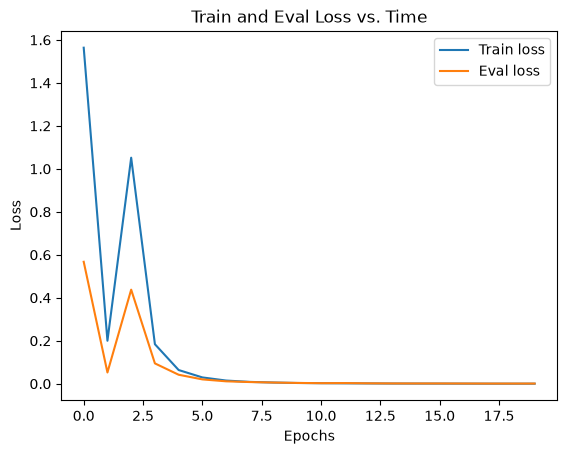

In [44]:
import matplotlib.pyplot as plt

epochs = np.arange(n_epochs)

plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, eval_losses, label="Eval loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Train and Eval Loss vs. Time")
plt.legend()
plt.show()

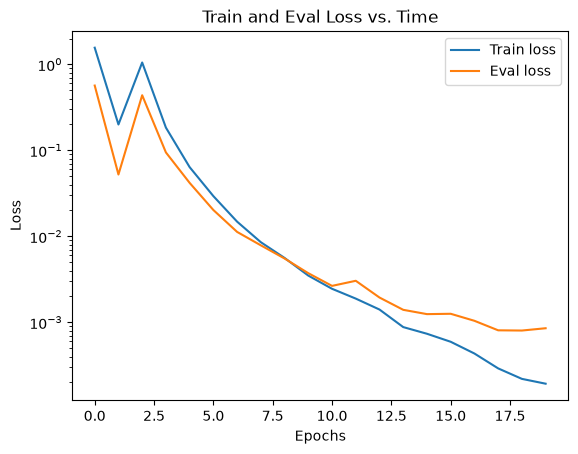

In [45]:
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, eval_losses, label="Eval loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Train and Eval Loss vs. Time")
plt.yscale("log")
plt.legend()
plt.show()